# Experiment 7

## Aim

To implement a Multilayer Perceptron (MLP) for multi-class classification using the Iris dataset.

## Theory

A Multilayer Perceptron (MLP) is a feedforward Artificial Neural Network consisting of:

• Input Layer
• One or More Hidden Layers
• Output Layer

Each neuron in one layer is connected to every neuron in the next layer.

MLPs use the Backpropagation algorithm to update weights and minimize prediction error.

Activation Function:
ReLU

Optimizer:
Adam

Output:
Three classes (Setosa, Versicolor, Virginica)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [4]:
model = MLPClassifier(
    hidden_layer_sizes=(10,5),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

print("MLP Model Trained Successfully")

MLP Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
y_pred = model.predict(X_test)

print("Predicted Classes")

print(y_pred)

Predicted Classes
[1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [6]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9666666666666667


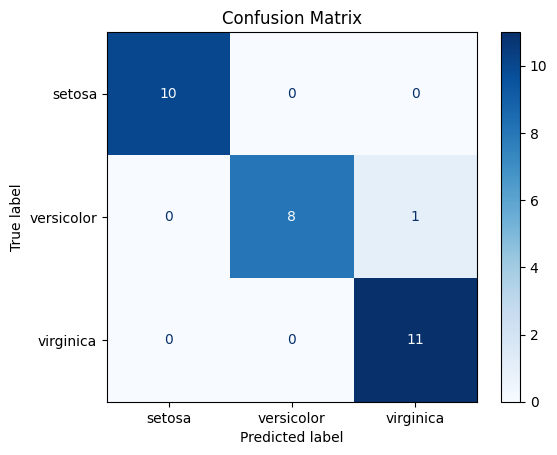

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

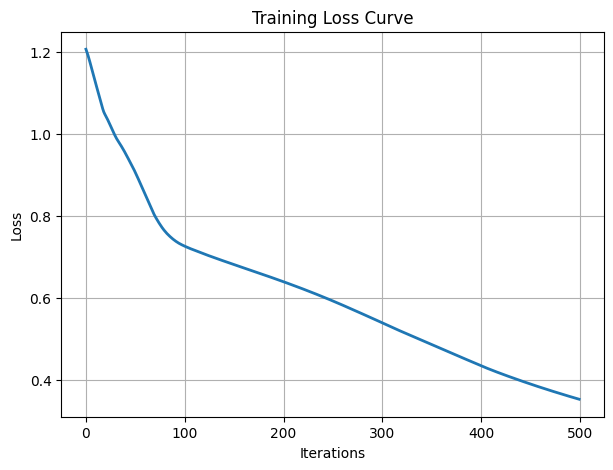

In [8]:
plt.figure(figsize=(7,5))

plt.plot(model.loss_curve_,
         linewidth=2)

plt.title("Training Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [9]:
print("Actual\tPredicted")

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(actual, "\t", predicted)

Actual	Predicted
1 	 1
0 	 0
2 	 2
1 	 1
1 	 1
0 	 0
1 	 1
2 	 2
1 	 2
1 	 1
